In [ ]:
!pip install pennylane pennylane-lightning pennylane-qiskit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 1.6 M

In [ ]:
!pip install torchvision torch torchaudio


In [ ]:
import os, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pennylane as qml


In [ ]:
!unzip /content/BreastMNIST_2000-20260126T072630Z-1-001.zip -d /content/BreastMNIST_2000


Archive:  /content/BreastMNIST_2000-20260126T072630Z-1-001.zip
  inflating: /content/BreastMNIST_2000/BreastMNIST_2000/normal/orig_00372.png  
  inflating: /content/BreastMNIST_2000/BreastMNIST_2000/normal/aug_00248.png  
  inflating: /content/BreastMNIST_2000/BreastMNIST_2000/malignant/aug_00381.png  
  inflating: /content/BreastMNIST_2000/BreastMNIST_2000/normal/orig_00203.png  
  inflating: /content/BreastMNIST_2000/BreastMNIST_2000/normal/orig_00545.png  
  inflating: /content/BreastMNIST_2000/BreastMNIST_2000/normal/orig_00231.png  
  inflating: /content/BreastMNIST_2000/BreastMNIST_2000/malignant/aug_00005.png  
  inflating: /content/BreastMNIST_2000/BreastMNIST_2000/normal/aug_00067.png  
  inflating: /content/BreastMNIST_2000/BreastMNIST_2000/normal/aug_00127.png  
  inflating: /content/BreastMNIST_2000/BreastMNIST_2000/malignant/aug_00857.png  
  inflating: /content/BreastMNIST_2000/BreastMNIST_2000/normal/aug_00208.png  
  inflating: /content/BreastMNIST_2000/BreastMNIST_2000

In [ ]:
!ls /content/BreastMNIST_2000


BreastMNIST_2000


In [ ]:
!ls /content/BreastMNIST_2000/BreastMNIST_2000


malignant  normal


In [ ]:
!ls /content/BreastMNIST_2000/BreastMNIST_2000/normal | head


aug_00000.png
aug_00001.png
aug_00002.png
aug_00003.png
aug_00004.png
aug_00005.png
aug_00006.png
aug_00007.png
aug_00008.png
aug_00009.png


In [ ]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DATA_ROOT = "/content/BreastMNIST_2000/BreastMNIST_2000"

IMG_SIZE = 128
BATCH_SIZE = 32
NUM_WORKERS = 2

EFFNET_EPOCHS = 25
HYBRID_EPOCHS = 30
LEARNING_RATE = 3e-4

N_QUBITS = 4
N_Q_LAYERS = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


In [ ]:
dataset_full = datasets.ImageFolder(DATA_ROOT, transform=transform)
classes = dataset_full.classes

targets = np.array([s[1] for s in dataset_full.samples])
idx = np.arange(len(targets))

train_idx, test_idx = train_test_split(
    idx, test_size=0.2, stratify=targets, random_state=SEED)

val_idx, test_idx = train_test_split(
    test_idx, test_size=0.5, stratify=targets[test_idx], random_state=SEED)

train_dataset = Subset(dataset_full, train_idx)
val_dataset = Subset(dataset_full, val_idx)
test_dataset = Subset(dataset_full, test_idx)

print("Classes:", dataset_full.classes)
print("Total images:", len(dataset_full))


Classes: ['malignant', 'normal']
Total images: 2000


In [ ]:
train_labels = targets[train_idx]
class_counts = np.bincount(train_labels)

class_weights = {i: 1.0 / c for i, c in enumerate(class_counts)}
sample_weights = [class_weights[l] for l in train_labels]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=NUM_WORKERS)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [ ]:
from sklearn.metrics import accuracy_score
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += x.size(0)

    avg_loss = total_loss / total
    acc = 100 * correct / total

    return avg_loss, acc


def evaluate(model, loader, device):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)

            outputs = model(x)
            preds = outputs.argmax(dim=1).cpu().numpy()

            y_true.extend(y.numpy())
            y_pred.extend(preds)

    acc = accuracy_score(y_true, y_pred) * 100

    return acc, y_true, y_pred


In [ ]:
def train_with_history(model, train_loader, val_loader, optimizer, criterion, device, epochs, tag="Model"):
    train_acc_hist = []
    val_acc_hist = []
    train_loss_hist = []
    val_loss_hist = []

    for epoch in range(epochs):

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )

        val_acc, _, _ = evaluate(model, val_loader, device)
        #scheduler.step(val_acc)

        # compute val loss
        model.eval()
        vloss = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                vloss += loss.item() * x.size(0)

        val_loss = vloss / len(val_loader.dataset)

        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)
        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)

        print(f"[{tag}] Epoch {epoch+1}: Train Acc={train_acc:.2f}% Val Acc={val_acc:.2f}%")

    return train_acc_hist, val_acc_hist, train_loss_hist, val_loss_hist


In [ ]:
import time

def train_with_time(model, train_loader, val_loader, optimizer, criterion, device, epochs, tag="Model"):
    start_total = time.time()

    train_acc_hist = []
    val_acc_hist = []
    epoch_times = []

    for epoch in range(epochs):

        t0 = time.time()

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )

        val_acc, _, _ = evaluate(model, val_loader, device)

        t1 = time.time()
        epoch_time = t1 - t0
        epoch_times.append(epoch_time)

        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)

        print(f"[{tag}] Epoch {epoch+1} | Acc={train_acc:.2f}% | Val={val_acc:.2f}% | Time={epoch_time:.2f}s")

    total_time = time.time() - start_total

    print(f"\n[{tag}] TOTAL TRAIN TIME: {total_time:.2f} sec")
    print(f"[{tag}] AVG EPOCH TIME: {sum(epoch_times)/len(epoch_times):.2f} sec")

    return train_acc_hist, val_acc_hist, epoch_times, total_time


In [ ]:
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch")
def qnode(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS))
    qml.BasicEntanglerLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]


class QNNAux(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(
            0.01 * torch.randn(N_Q_LAYERS, N_QUBITS, dtype=torch.float32)
        )

    def forward(self, x):
        outputs = []
        for sample in x:
            sample = torch.tanh(sample) * np.pi
            q_out = qnode(sample, self.weights)   # q_out is a list

            # ✅ Proper conversion: list → torch tensor (float32)
            q_out = torch.stack(q_out).float()

            outputs.append(q_out)

        return torch.stack(outputs)



In [ ]:
class EfficientNetClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.efficientnet_v2_s(pretrained=True)

        self.backbone.classifier[1] = nn.Linear(
            self.backbone.classifier[1].in_features,
            num_classes
        )

    def forward(self, x):
        x = x.repeat(1, 3, 1, 1)   # 1→3 channel
        return self.backbone(x)


In [ ]:
class HybridEfficientNetQNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        eff = models.efficientnet_v2_s(pretrained=True)
        self.features = eff.features
        self.pool = nn.AdaptiveAvgPool2d(1)

        self.feature_dim = 1280

        self.projector = nn.Sequential(
            nn.Linear(self.feature_dim, 128),
            nn.ReLU(),
            nn.Linear(128, N_QUBITS)
        )

        self.qnn = QNNAux()

        self.summary = nn.Sequential(
            nn.Linear(self.feature_dim, 32),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Linear(N_QUBITS + 32, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x.repeat(1, 3, 1, 1)
        feat = self.pool(self.features(x)).flatten(1)

        q_in = self.projector(feat)
        q_out = self.qnn(q_in)

        summary = self.summary(feat)
        combined = torch.cat([q_out, summary], dim=1)

        return self.classifier(combined)


In [ ]:
#baseline = EfficientNetClassifier(len(classes)).to(DEVICE)
#criterion = nn.CrossEntropyLoss()
#optimizer = optim.Adam(baseline.parameters(), lr=LEARNING_RATE)

#for epoch in range(EFFNET_EPOCHS):
 #   loss, acc = train_one_epoch(baseline, train_loader, optimizer, criterion, DEVICE)
  #  val_acc, _, _ = evaluate(baseline, val_loader, DEVICE)
   # print(f"[EffNet] Epoch {epoch+1}: Train Acc={acc:.2f}% Val Acc={val_acc:.2f}%")
baseline = EfficientNetClassifier(len(classes)).to(DEVICE)
for p in baseline.backbone.features.parameters():
    p.requires_grad = False

#optimizer = optim.Adam(baseline.parameters(), lr=LEARNING_RATE)
optimizer = optim.Adam(
    baseline.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)

criterion = nn.CrossEntropyLoss()

eff_train_acc, eff_val_acc, eff_epoch_times1, eff_time1 = train_with_time(
    baseline,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    DEVICE,
    5,
    tag="EffNet-Frozen"
)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_V2_S_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:01<00:00, 55.4MB/s]


[EffNet-Frozen] Epoch 1 | Acc=55.62% | Val=50.00% | Time=140.56s
[EffNet-Frozen] Epoch 2 | Acc=58.44% | Val=64.00% | Time=122.95s
[EffNet-Frozen] Epoch 3 | Acc=62.31% | Val=59.50% | Time=124.19s
[EffNet-Frozen] Epoch 4 | Acc=63.94% | Val=70.00% | Time=124.51s
[EffNet-Frozen] Epoch 5 | Acc=66.88% | Val=71.00% | Time=125.26s

[EffNet-Frozen] TOTAL TRAIN TIME: 637.47 sec
[EffNet-Frozen] AVG EPOCH TIME: 127.49 sec


In [ ]:
for p in baseline.backbone.features.parameters():
    p.requires_grad = True

optimizer = optim.Adam(
    baseline.parameters(),
    lr=LEARNING_RATE * 0.5,   # smaller LR for fine tuning
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)

eff_train_acc2, eff_val_acc2, eff_epoch_times2, eff_time2  = train_with_time(
    baseline,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    DEVICE,
    20,
    tag="EffNet-Finetune"
)


[EffNet-Finetune] Epoch 1 | Acc=78.94% | Val=76.50% | Time=334.56s
[EffNet-Finetune] Epoch 2 | Acc=89.81% | Val=82.00% | Time=336.06s
[EffNet-Finetune] Epoch 3 | Acc=94.50% | Val=82.50% | Time=333.08s
[EffNet-Finetune] Epoch 4 | Acc=97.19% | Val=84.50% | Time=332.26s
[EffNet-Finetune] Epoch 5 | Acc=98.19% | Val=84.00% | Time=328.76s
[EffNet-Finetune] Epoch 6 | Acc=98.62% | Val=85.00% | Time=328.13s
[EffNet-Finetune] Epoch 7 | Acc=98.19% | Val=83.50% | Time=333.29s
[EffNet-Finetune] Epoch 8 | Acc=98.31% | Val=82.00% | Time=329.76s
[EffNet-Finetune] Epoch 9 | Acc=98.00% | Val=85.50% | Time=328.77s
[EffNet-Finetune] Epoch 10 | Acc=98.75% | Val=82.00% | Time=328.65s
[EffNet-Finetune] Epoch 11 | Acc=99.31% | Val=84.00% | Time=331.27s
[EffNet-Finetune] Epoch 12 | Acc=99.25% | Val=84.50% | Time=333.84s
[EffNet-Finetune] Epoch 13 | Acc=99.31% | Val=82.00% | Time=344.48s
[EffNet-Finetune] Epoch 14 | Acc=99.19% | Val=86.00% | Time=340.69s
[EffNet-Finetune] Epoch 15 | Acc=99.31% | Val=85.00% | Ti

In [ ]:
# merge phase1 + phase2 history
eff_train_acc += eff_train_acc2
eff_val_acc += eff_val_acc2


In [ ]:
torch.save(baseline.state_dict(), "efficientnetv2_baseline_best.pth")


In [ ]:
#hybrid = HybridEfficientNetQNN(len(classes))
#HYBRID_DEVICE = torch.device("cpu")

#criterion = nn.CrossEntropyLoss()
#optimizer = optim.Adam(hybrid.parameters(), lr=LEARNING_RATE)

#for epoch in range(HYBRID_EPOCHS):
 #   loss, acc = train_one_epoch(hybrid, train_loader, optimizer, criterion, HYBRID_DEVICE)
  #  val_acc, _, _ = evaluate(hybrid, val_loader, HYBRID_DEVICE)
   # print(f"[Hybrid] Epoch {epoch+1}: Train Acc={acc:.2f}% Val Acc={val_acc:.2f}%")
HYBRID_DEVICE = torch.device("cpu")

hybrid = HybridEfficientNetQNN(len(classes))

for p in hybrid.features.parameters():
    p.requires_grad = False

optimizer = optim.Adam(
    hybrid.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

hyb_train_acc, hyb_val_acc, hyb_epoch_times1, hyb_time1 = train_with_time(
    hybrid,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    HYBRID_DEVICE,
    8,
    tag="Hybrid-Frozen"
)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_V2_S_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[Hybrid-Frozen] Epoch 1 | Acc=53.12% | Val=46.00% | Time=159.19s
[Hybrid-Frozen] Epoch 2 | Acc=59.00% | Val=61.50% | Time=162.20s
[Hybrid-Frozen] Epoch 3 | Acc=65.06% | Val=65.00% | Time=158.69s
[Hybrid-Frozen] Epoch 4 | Acc=66.06% | Val=63.50% | Time=164.90s
[Hybrid-Frozen] Epoch 5 | Acc=70.25% | Val=67.00% | Time=157.42s
[Hybrid-Frozen] Epoch 6 | Acc=67.06% | Val=70.50% | Time=161.72s
[Hybrid-Frozen] Epoch 7 | Acc=70.44% | Val=71.00% | Time=162.84s
[Hybrid-Frozen] Epoch 8 | Acc=70.88% | Val=72.50% | Time=161.35s

[Hybrid-Frozen] TOTAL TRAIN TIME: 1288.31 sec
[Hybrid-Frozen] AVG EPOCH TIME: 161.04 sec


In [ ]:
for p in hybrid.features.parameters():
    p.requires_grad = True

optimizer = optim.Adam(
    hybrid.parameters(),
    lr=LEARNING_RATE * 0.5,
    weight_decay=1e-4
)

hyb_train_acc2, hyb_val_acc2, hyb_epoch_times2, hyb_time2 = train_with_time(
    hybrid,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    HYBRID_DEVICE,
    22,
    tag="Hybrid-Finetune"
)


[Hybrid-Finetune] Epoch 1 | Acc=76.88% | Val=73.50% | Time=378.13s
[Hybrid-Finetune] Epoch 2 | Acc=88.50% | Val=78.50% | Time=374.42s
[Hybrid-Finetune] Epoch 3 | Acc=94.12% | Val=74.50% | Time=376.42s
[Hybrid-Finetune] Epoch 4 | Acc=94.88% | Val=83.00% | Time=376.26s
[Hybrid-Finetune] Epoch 5 | Acc=96.69% | Val=81.00% | Time=359.78s
[Hybrid-Finetune] Epoch 6 | Acc=96.62% | Val=83.00% | Time=360.16s
[Hybrid-Finetune] Epoch 7 | Acc=97.06% | Val=83.00% | Time=360.25s
[Hybrid-Finetune] Epoch 8 | Acc=98.31% | Val=82.50% | Time=353.04s
[Hybrid-Finetune] Epoch 9 | Acc=98.56% | Val=84.50% | Time=360.09s
[Hybrid-Finetune] Epoch 10 | Acc=98.56% | Val=82.00% | Time=363.24s
[Hybrid-Finetune] Epoch 11 | Acc=97.94% | Val=81.50% | Time=354.19s
[Hybrid-Finetune] Epoch 12 | Acc=99.38% | Val=81.00% | Time=362.76s
[Hybrid-Finetune] Epoch 13 | Acc=98.62% | Val=83.00% | Time=354.83s
[Hybrid-Finetune] Epoch 14 | Acc=98.88% | Val=83.50% | Time=352.89s
[Hybrid-Finetune] Epoch 15 | Acc=98.69% | Val=84.50% | Ti

In [ ]:
# merge phase1 + phase2 history
hyb_train_acc += hyb_train_acc2
hyb_val_acc += hyb_val_acc2


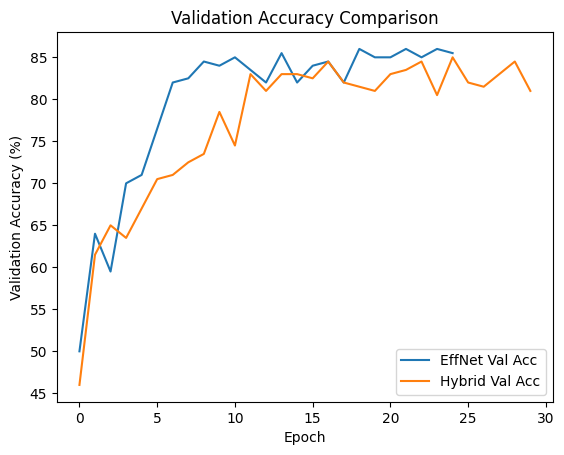

In [ ]:
#plotting accuracy graphs
import matplotlib.pyplot as plt

plt.figure()
plt.plot(eff_val_acc, label="EffNet Val Acc")
plt.plot(hyb_val_acc, label="Hybrid Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()


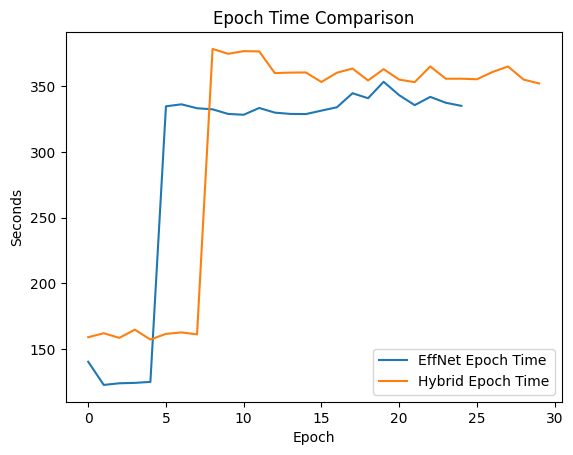

In [ ]:
#plotting Epoch Time Plot
plt.figure()
plt.plot(eff_epoch_times1 + eff_epoch_times2, label="EffNet Epoch Time")
plt.plot(hyb_epoch_times1 + hyb_epoch_times2, label="Hybrid Epoch Time")
plt.xlabel("Epoch")
plt.ylabel("Seconds")
plt.title("Epoch Time Comparison")
plt.legend()
plt.show()



In [ ]:
#Final Test Evaluation (both models)
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def test_metrics(model, loader, device, name):
    acc, y_true, y_pred = evaluate(model, loader, device)

    print(f"\n{name} Test Accuracy: {acc:.2f}%")
    print(classification_report(y_true, y_pred, target_names=classes))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()



EfficientNetV2 Test Accuracy: 85.50%
              precision    recall  f1-score   support

   malignant       0.88      0.93      0.90       146
      normal       0.78      0.65      0.71        54

    accuracy                           0.85       200
   macro avg       0.83      0.79      0.81       200
weighted avg       0.85      0.85      0.85       200



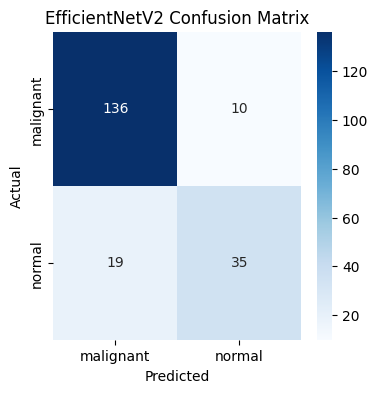


Hybrid QNN Test Accuracy: 88.00%
              precision    recall  f1-score   support

   malignant       0.88      0.97      0.92       146
      normal       0.89      0.63      0.74        54

    accuracy                           0.88       200
   macro avg       0.89      0.80      0.83       200
weighted avg       0.88      0.88      0.87       200



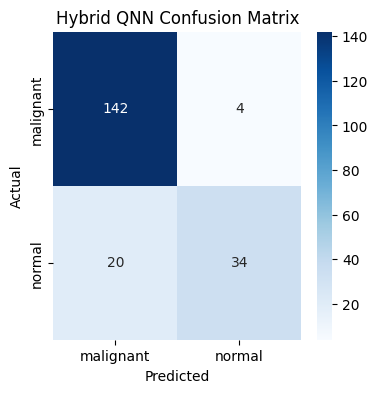

In [ ]:
#run both the models
test_metrics(baseline, test_loader, DEVICE, "EfficientNetV2")
test_metrics(hybrid, test_loader, HYBRID_DEVICE, "Hybrid QNN")


In [ ]:
print("\n===== TRAINING TIME SUMMARY =====")
print("EffNet total:", eff_time1 + eff_time2, "sec")
print("Hybrid total:", hyb_time1 + hyb_time2, "sec")



===== TRAINING TIME SUMMARY =====
EffNet total: 7346.513526916504 sec
Hybrid total: 9237.873095750809 sec


In [ ]:
def measure_inference_time(model, loader, device, name):
    model.eval()
    batch_times = []

    with torch.no_grad():
        for i, (x, _) in enumerate(loader):
            if i == 30:   # measure first 30 batches only
                break
            x = x.to(device)

            t0 = time.time()
            _ = model(x)
            t1 = time.time()

            batch_times.append(t1 - t0)

    avg_batch = sum(batch_times) / len(batch_times)
    per_image = avg_batch / loader.batch_size

    print(f"\n{name} Inference:")
    print(f"Avg batch time: {avg_batch:.4f} sec")
    print(f"Per image time: {per_image:.6f} sec")

    return avg_batch, per_image


In [ ]:
measure_inference_time(baseline, test_loader, DEVICE, "EfficientNetV2-S")
measure_inference_time(hybrid, test_loader, HYBRID_DEVICE, "Hybrid QNN")



EfficientNetV2-S Inference:
Avg batch time: 1.4926 sec
Per image time: 0.046643 sec

Hybrid QNN Inference:
Avg batch time: 1.7839 sec
Per image time: 0.055746 sec


(1.7838796547480993, 0.0557462392108781)

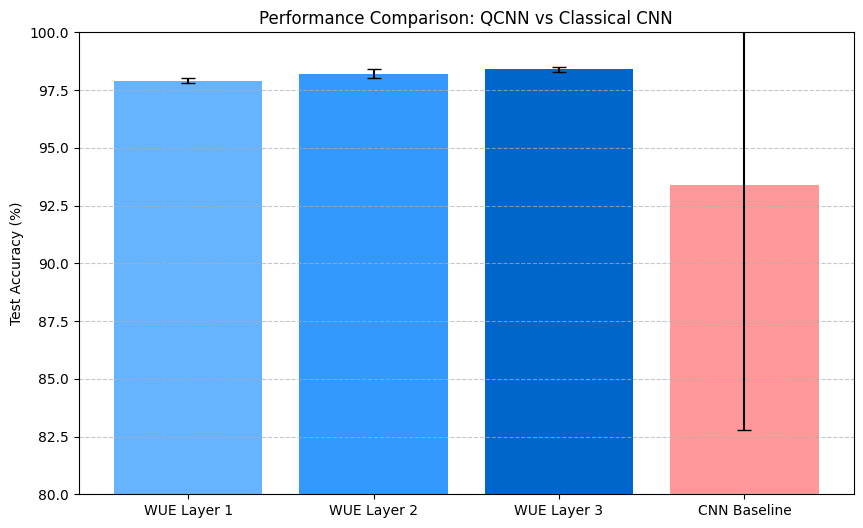

In [ ]:

import matplotlib.pyplot as plt

# Data taken from your Table 6 results
labels = ['WUE Layer 1', 'WUE Layer 2', 'WUE Layer 3', 'CNN Baseline']
accuracy = [97.9, 98.2, 98.4, 93.4]
errors = [0.1, 0.2, 0.1, 10.6] # Standard deviation from your table

plt.figure(figsize=(10, 6))
plt.bar(labels, accuracy, yerr=errors, capsize=5, color=['#66b3ff', '#3399ff', '#0066cc', '#ff9999'])
plt.ylim(80, 100)
plt.ylabel('Test Accuracy (%)')
plt.title('Performance Comparison: QCNN vs Classical CNN')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

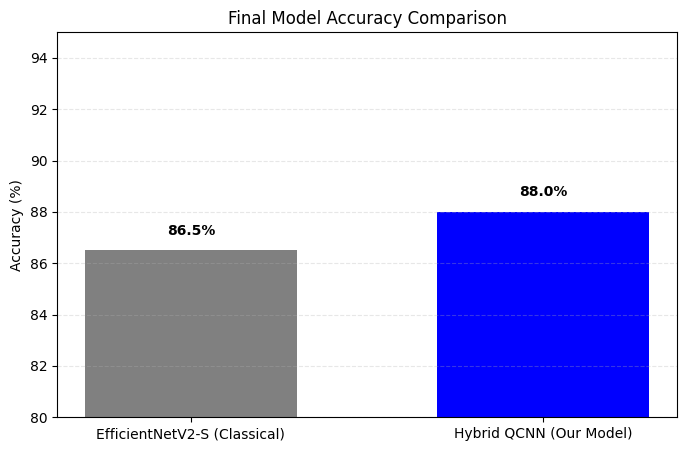

In [ ]:

import matplotlib.pyplot as plt

# Data from your specific results (Table 2)
models = ['EfficientNetV2-S (Classical)', 'Hybrid QCNN (Our Model)']
accuracy = [86.5, 88.0]

plt.figure(figsize=(8, 5))
colors = ['gray', 'blue']
bars = plt.bar(models, accuracy, color=colors, width=0.6)

# Adding labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval}%', ha='center', va='bottom', fontweight='bold')

plt.ylim(80, 95)
plt.ylabel('Accuracy (%)')
plt.title('Final Model Accuracy Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

In [ ]:
def test_metrics(model, loader, device, name):
    acc, y_true, y_pred = evaluate(model, loader, device)

    print(f"\n{name} Test Accuracy: {acc:.2f}%")

    return acc   # ✅ IMPORTANT

In [ ]:
eff_breast = test_metrics(baseline, test_loader, DEVICE, "EfficientNet BreastMNIST")
hyb_breast = test_metrics(hybrid, test_loader, HYBRID_DEVICE, "Hybrid BreastMNIST")

print("\n==== BreastMNIST Final Results ====")
print(f"EfficientNet Accuracy: {eff_breast:.2f}%")
print(f"Hybrid QNN Accuracy: {hyb_breast:.2f}%")


EfficientNet BreastMNIST Test Accuracy: 85.50%

Hybrid BreastMNIST Test Accuracy: 88.00%

==== BreastMNIST Final Results ====
EfficientNet Accuracy: 85.50%
Hybrid QNN Accuracy: 88.00%


In [ ]:
import gradio as gr
import torch
from PIL import Image
import torchvision.transforms as transforms

# Load models
baseline.load_state_dict(torch.load("efficientnetv2_baseline_best.pth", map_location=DEVICE))
baseline.eval()


hybrid.eval()

# Transform (same as training)
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

classes = ["benign", "malignant"]

def predict(image):
    image = image.convert("L")
    img = transform(image).unsqueeze(0)

    # EfficientNet prediction
    img_eff = img.to(DEVICE)
    out_eff = baseline(img_eff)
    prob_eff = torch.softmax(out_eff, dim=1)
    pred_eff = classes[prob_eff.argmax().item()]
    conf_eff = prob_eff.max().item()

    # Hybrid prediction
    img_hyb = img.to(HYBRID_DEVICE)
    out_hyb = hybrid(img_hyb)
    prob_hyb = torch.softmax(out_hyb, dim=1)
    pred_hyb = classes[prob_hyb.argmax().item()]
    conf_hyb = prob_hyb.max().item()

    return (
        f"EfficientNet → {pred_eff} ({conf_eff:.2f})",
        f"Hybrid QNN → {pred_hyb} ({conf_hyb:.2f})"
    )

# Gradio UI
demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs=[
        gr.Textbox(label="EfficientNet Result"),
        gr.Textbox(label="Hybrid QNN Result")
    ],
    title="Breast Cancer Classification (Hybrid QNN)",
    description="Upload a histopathology image to classify as benign or malignant using EfficientNetV2-S and Hybrid QNN."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://970ed89c86067eee2b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
!ls

BreastMNIST_2000			     efficientnetv2_baseline_best.pth
BreastMNIST_2000-20260126T072630Z-1-001.zip  sample_data
